In [1]:
from google.colab import files
uploaded = files.upload()

Saving loan_default_dataset.zip to loan_default_dataset.zip


In [2]:
import os
print(os.listdir())

['.config', 'loan_default_dataset.zip', 'sample_data']


In [3]:
import zipfile

with zipfile.ZipFile("loan_default_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("loan_dataset")

print(os.listdir("loan_dataset"))

['Loan_Default.csv']


In [4]:
import pandas as pd

df = pd.read_csv("loan_dataset/Loan_Default.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [5]:
df.shape
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [6]:
# ===============================
# DATA LOADING + CLEANING
# ===============================

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("loan_dataset/Loan_Default.csv")

print("Original Shape:", df.shape)

# Drop ID column if exists
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Remove leakage columns (FIX: moved here)
leak_cols = [
    "credit_type",
    "co-applicant_credit_type",
    "Interest_rate_spread",
    "Upfront_charges",
    "rate_of_interest"
]

df = df.drop(columns=[col for col in leak_cols if col in df.columns])

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("After Removing Duplicates:", df.shape)

# Handle missing values
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Cleaning:", df.isnull().sum().sum())

# Outlier removal using IQR
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

important_cols = ["Credit_Score", "LTV", "dtir1"]

for col in important_cols:
    if col in df.columns:
        df = remove_outliers_iqr(df, col)

df = df.reset_index(drop=True)

print("After Outlier Removal:", df.shape)

# Save cleaned CSV
df.to_csv("loan_cleaned.csv", index=False)
print("Clean dataset saved as loan_cleaned.csv")


Original Shape: (148670, 34)
After Removing Duplicates: (148668, 28)
Missing Values After Cleaning: 0
After Outlier Removal: (137375, 28)
Clean dataset saved as loan_cleaned.csv


In [7]:
# ===============================
# SQLITE DATABASE STORAGE
# ===============================

import sqlite3

conn = sqlite3.connect("creditpathai.db")

# Store cleaned data
df.to_sql("clean_loans", conn, if_exists="replace", index=False)

# Check tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables inside database:")
print(tables)

conn.close()

print("Database integration completed successfully.")


Tables inside database:
          name
0  clean_loans
Database integration completed successfully.


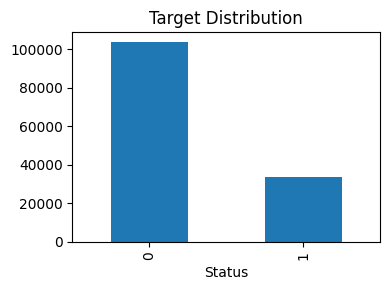

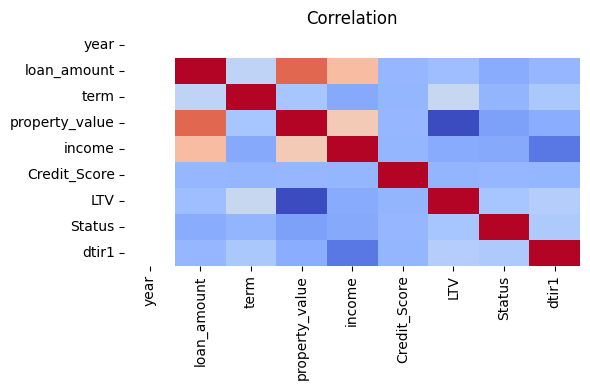

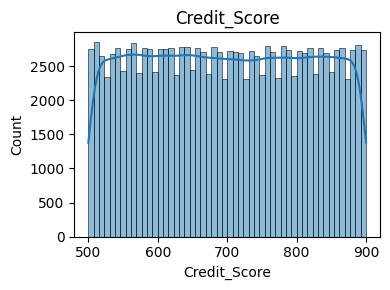

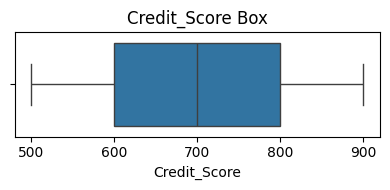

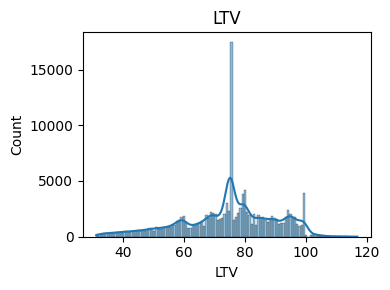

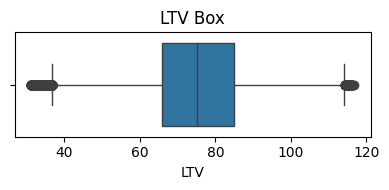

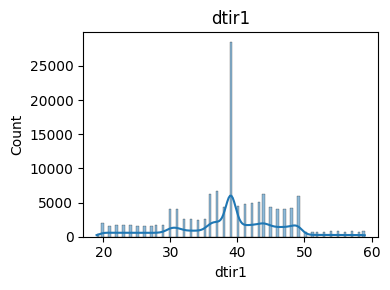

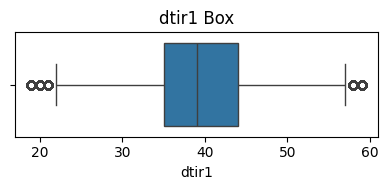

In [8]:
# ===============================
# COMPACT EDA (SMALL GRAPHS)
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# Target distribution
plt.figure(figsize=(4,3))
df["Status"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.tight_layout()
plt.show()

# Correlation heatmap (small)
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", cbar=False)
plt.title("Correlation")
plt.tight_layout()
plt.show()

# Important features
important_cols = ["Credit_Score", "LTV", "dtir1"]

for col in important_cols:
    if col in df.columns:

        # Histogram
        plt.figure(figsize=(4,3))
        sns.histplot(df[col], kde=True)
        plt.title(col)
        plt.tight_layout()
        plt.show()

        # Boxplot
        plt.figure(figsize=(4,2))
        sns.boxplot(x=df[col])
        plt.title(f"{col} Box")
        plt.tight_layout()
        plt.show()


In [9]:
# ===============================
# IMPROVED BASE MODEL
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# Load cleaned data
df = pd.read_csv("loan_cleaned.csv")

# ===============================
# FEATURE ENGINEERING (STRONGER)
# ===============================

def safe_divide(a, b):
    return a / (b + 1)

# Core ratios
if "loan_amount" in df.columns and "income" in df.columns:
    df["loan_to_income_ratio"] = safe_divide(df["loan_amount"], df["income"])

if "loan_amount" in df.columns and "income" in df.columns:
    df["payment_to_income_ratio"] = safe_divide(df["loan_amount"], df["income"])

# NEW FEATURES 🔥
if "dtir1" in df.columns:
    df["high_dti_flag"] = (df["dtir1"] > 40).astype(int)


if "Credit_Score" in df.columns:
    df["low_credit_flag"] = (df["Credit_Score"] < 650).astype(int)

if "LTV" in df.columns:
    df["high_ltv_flag"] = (df["LTV"] > 80).astype(int)


# Interaction features 🔥
if "loan_to_income_ratio" in df.columns and "dtir1" in df.columns:
    df["risk_interaction"] = df["loan_to_income_ratio"] * df["dtir1"]

# Log transforms
for col in ["income", "revolving_balance"]:
    if col in df.columns:
        df["log_" + col] = np.log1p(df[col])

# Credit stress
if "LTV" in df.columns and "Credit_Score" in df.columns:
    df["credit_stress_index"] = df["LTV"] * (700 - df["Credit_Score"])

# ===============================
# PREPARE DATA
# ===============================

X = df.drop("Status", axis=1)
y = df["Status"]

X = pd.get_dummies(X, drop_first=True)

# ===============================
# SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# SCALING
# ===============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# TUNED LOGISTIC REGRESSION 🔥
# ===============================

model = LogisticRegression(
    max_iter=2000,
    C=0.5,                  # regularization tuning
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

# ===============================
# EVALUATION
# ===============================

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Improved Accuracy:", accuracy_score(y_test, y_pred))
print("Improved ROC-AUC:", roc_auc_score(y_test, y_prob))


Improved Accuracy: 0.7240764331210191
Improved ROC-AUC: 0.7873501854409161


In [10]:
# ===============================
# CHECK OVERFITTING
# ===============================

# Train predictions
y_train_pred = model.predict(X_train_scaled)
y_train_prob = model.predict_proba(X_train_scaled)[:, 1]

# Test predictions (already done)
y_test_pred = model.predict(X_test_scaled)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

# Scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

print("Train ROC-AUC:", train_auc)
print("Test ROC-AUC :", test_auc)


Train Accuracy: 0.7279890809827115
Test Accuracy : 0.7240764331210191
Train ROC-AUC: 0.7905503872032651
Test ROC-AUC : 0.7873501854409161


In [13]:
# ===============================
# ADVANCED MODELS
# ===============================

from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score   # ✅ added

# -------- XGBOOST --------
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_xgb,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)
# ===== FIX COLUMN NAMES FOR XGBOOST =====
import re

def clean_column_names(df):
    df.columns = [re.sub(r'[\[\]<]', '', str(col)) for col in df.columns]
    return df

X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)

# ensure all are strings
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:,1]

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("Tuned XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print("Best XGBoost Params:", xgb_random.best_params_)


# -------- LIGHTGBM --------
lgb_model = lgb.LGBMClassifier(random_state=42)

param_lgb = {
    "n_estimators": [100, 200],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50],
    "subsample": [0.8, 0.9]
}

lgb_random = RandomizedSearchCV(
    lgb_model,
    param_distributions=param_lgb,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

lgb_random.fit(X_train, y_train)

best_lgb = lgb_random.best_estimator_

lgb_pred = best_lgb.predict(X_test)
lgb_prob = best_lgb.predict_proba(X_test)[:,1]

print("Tuned LightGBM Accuracy:", accuracy_score(y_test, lgb_pred))
print("Tuned LightGBM ROC-AUC:", roc_auc_score(y_test, lgb_prob))
print("Best LightGBM Params:", lgb_random.best_params_)


Tuned XGBoost Accuracy: 0.8975068243858053
Tuned XGBoost ROC-AUC: 0.8973674931834044
Best XGBoost Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 26951, number of negative: 82949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2593
[LightGBM] [Info] Number of data points in the train set: 109900, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.245232 -> initscore=-1.124206
[LightGBM] [Info] Start training from score -1.124206
Tuned LightGBM Accuracy: 0.8976888080072793
Tuned LightGBM ROC-AUC: 0.8974548177200583
Best LightGBM Params: {'subsample': 0.8, 'num_leaves': 31, 'n_est

In [14]:
# Train predictions
xgb_train_prob = best_xgb.predict_proba(X_train)[:,1]

print("Train ROC-AUC:", roc_auc_score(y_train, xgb_train_prob))
print("Test ROC-AUC :", roc_auc_score(y_test, xgb_prob))


Train ROC-AUC: 0.9114947289062195
Test ROC-AUC : 0.8973674931834044


In [16]:
borrower_sample = X.iloc[[0]]

# scale input first
borrower_scaled = scaler.transform(borrower_sample)

prob = model.predict_proba(borrower_scaled)[0][1]

loan_amount = df.iloc[0]["loan_amount"]

expected_loss = prob * loan_amount

print("Default Probability:", prob)
print("Loan Amount:", loan_amount)
print("Expected Loss:", expected_loss)





Default Probability: 0.5250882995911669
Loan Amount: 116500
Expected Loss: 61172.78690237094


In [19]:
def expected_loss_engine(model, borrower_row):

    # borrower_row should be a single row dataframe
    input_data = borrower_row.drop(columns=["Status"])

    # Step 1: Predict default probability
    prob = model.predict_proba(input_data)[0][1]

    # Step 2: Get loan amount (Exposure)
    loan_amount = borrower_row["loan_amount"].values[0]

    # Step 3: Calculate Expected Loss
    expected_loss = prob * loan_amount

    # Step 4: Decision Engine
    if expected_loss < 50000:
        decision = {
            "priority": "Low",
            "assigned_team": "Automated System",
            "recovery_channel": "Email + SMS Reminder",
            "follow_up_frequency": "Once in 15 days",
            "legal_action": False
        }

    elif expected_loss < 200000:
        decision = {
            "priority": "Medium",
            "assigned_team": "Call Center Agent",
            "recovery_channel": "Phone Call + EMI Restructure Offer",
            "follow_up_frequency": "Weekly",
            "legal_action": False
        }

    elif expected_loss < 500000:
        decision = {
            "priority": "High",
            "assigned_team": "Dedicated Recovery Officer",
            "recovery_channel": "Direct Call + Field Visit",
            "follow_up_frequency": "Every 5 days",
            "legal_action": False
        }

    else:
        decision = {
            "priority": "Critical",
            "assigned_team": "Senior Recovery & Legal Team",
            "recovery_channel": "Legal Notice + Field Investigation",
            "follow_up_frequency": "Every 3 days",
            "legal_action": True
        }

    return {
        "default_probability": float(prob),
        "loan_amount": float(loan_amount),
        "expected_loss": float(expected_loss),
        "decision_plan": decision
    }


In [20]:
sample_X = X.iloc[:100]

# scale the features
sample_X_scaled = scaler.transform(sample_X)

probs = model.predict_proba(sample_X_scaled)[:,1]

loan_amounts = df.iloc[:100]["loan_amount"].values

expected_losses = probs * loan_amounts

risk_table = sample_X.copy()
risk_table["default_probability"] = probs
risk_table["loan_amount"] = loan_amounts
risk_table["expected_loss"] = expected_losses

risk_table.head()


,year,loan_amount,term,property_value,income,Credit_Score,LTV,dtir1,loan_to_income_ratio,payment_to_income_ratio,...,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct,default_probability,expected_loss
0,2019,116500,360.0,118000.0,1740.0,758,98.728814,45.0,66.915566,66.915566,...,False,False,False,True,False,False,True,True,0.525088,61172.786902
1,2019,206500,360.0,418000.0,4980.0,552,75.135870,39.0,41.457539,41.457539,...,False,False,False,True,False,False,False,True,0.976513,201649.870161
2,2019,406500,360.0,508000.0,9480.0,834,80.019685,46.0,42.875224,42.875224,...,False,False,False,True,False,False,True,True,0.414519,168502.044468
3,2019,456500,360.0,658000.0,11880.0,587,69.376900,42.0,38.422692,38.422692,...,False,False,False,False,False,False,False,True,0.149610,68296.964471
4,2019,696500,360.0,758000.0,10440.0,602,91.886544,39.0,66.708170,66.708170,...,False,False,False,False,False,False,False,True,0.309780,215761.967723


In [24]:
# ============================================
# CREDITPATH AI - ADVANCED RECOMMENDATION ENGINE
# ============================================

def generate_recommendation(row):

    prob = row["default_probability"]
    expected_loss = row["expected_loss"]
    loan_amount = row["loan_amount"]

    # ------------------------------
    # Risk Classification
    # ------------------------------
    if prob < 0.20:
        risk_level = "Very Low Risk"

    elif prob < 0.40:
        risk_level = "Low Risk"

    elif prob < 0.60:
        risk_level = "Moderate Risk"

    elif prob < 0.80:
        risk_level = "High Risk"

    else:
        risk_level = "Critical Risk"

    # ------------------------------
    # Priority
    # ------------------------------
    if expected_loss < 30000:
        priority = "Low"

    elif expected_loss < 100000:
        priority = "Medium"

    elif expected_loss < 300000:
        priority = "High"

    else:
        priority = "Critical"

    # ------------------------------
    # Smart Recovery Action
    # ------------------------------
    if risk_level == "Very Low Risk":
        action = "Maintain normal monitoring"

    elif risk_level == "Low Risk":
        action = "Send automated repayment reminder"

    elif risk_level == "Moderate Risk":
        action = "Agent follow-up call and repayment counseling"

    elif risk_level == "High Risk":
        action = "Offer loan restructuring or flexible EMI plan"

    else:
        action = "Immediate recovery action and legal escalation"

    # ------------------------------
    # Preventive Suggestions
    # ------------------------------
    suggestions = []

    if prob > 0.6:
        suggestions.append("Review borrower credit policy")

    if loan_amount > 500000:
        suggestions.append("Consider reducing credit exposure")

    if expected_loss > 200000:
        suggestions.append("Increase monitoring frequency")

    if prob > 0.75:
        suggestions.append("Assign senior recovery agent")

    return pd.Series([risk_level, priority, action, ", ".join(suggestions)])


# Apply recommendation engine
risk_table[["risk_level",
            "priority_level",
            "recommended_action",
            "preventive_suggestions"]] = risk_table.apply(
    generate_recommendation, axis=1
)

# Show results
risk_table.head()

,year,loan_amount,term,property_value,income,Credit_Score,LTV,dtir1,loan_to_income_ratio,payment_to_income_ratio,...,Region_North-East,Region_central,Region_south,Security_Type_direct,default_probability,expected_loss,priority_level,recommended_action,risk_level,preventive_suggestions
0,2019,116500,360.0,118000.0,1740.0,758,98.728814,45.0,66.915566,66.915566,...,False,False,True,True,0.525088,61172.786902,Medium,Agent follow-up call and repayment counseling,Moderate Risk,
1,2019,206500,360.0,418000.0,4980.0,552,75.135870,39.0,41.457539,41.457539,...,False,False,False,True,0.976513,201649.870161,High,Immediate recovery action and legal escalation,Critical Risk,"Review borrower credit policy, Increase monito..."
2,2019,406500,360.0,508000.0,9480.0,834,80.019685,46.0,42.875224,42.875224,...,False,False,True,True,0.414519,168502.044468,High,Agent follow-up call and repayment counseling,Moderate Risk,
3,2019,456500,360.0,658000.0,11880.0,587,69.376900,42.0,38.422692,38.422692,...,False,False,False,True,0.149610,68296.964471,Medium,Maintain normal monitoring,Very Low Risk,
4,2019,696500,360.0,758000.0,10440.0,602,91.886544,39.0,66.708170,66.708170,...,False,False,False,True,0.309780,215761.967723,High,Send automated repayment reminder,Low Risk,"Consider reducing credit exposure, Increase mo..."
